# 0. 导入必要的库

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
from typing import List, Tuple, Optional, Dict, Any
import matplotlib.pyplot as plt
import numpy as np

# Import utility functions
import sys
sys.path.append('.')
from my_utils import (
    get_device,
    get_cifar10_data_augmentation,
    create_train_val_split,
    train_model,
    evaluate_accuracy,
    predict as predict_util,
    plot_loss_curves,
    count_parameters,
    create_learning_rate_scheduler
)

show = ToPILImage()

# 1. 准备训练数据与测试数据
首先我们介绍数据部分。`torchvision`库已经为我们直接提供了CIFAR-10数据集的下载，我们就不需要手动地去网上下载了。代码中的`transform`将原始的图像转换为模型易于处理的形式。`trainloader`和`testloader`分别用于加载训练集和测试集。

In [ ]:
# 设定对图片的归一化处理方式，并且下载数据集
import os
os.makedirs('./dataset', exist_ok=True)

# 使用工具函数获取数据增强变换
transform_train, transform_test = get_cifar10_data_augmentation()

batch_size = 64  # 根据RTX 4090调整，从4增加到64

# 加载完整训练集
full_trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True,
                                        download=True, transform=transform_train)

# 使用工具函数分割训练集和验证集（90%训练，10%验证）
trainset, valset = create_train_val_split(full_trainset, val_ratio=0.1, seed=42)

# 创建数据加载器
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

# 测试集
testset = torchvision.datasets.CIFAR10(root='./dataset', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

print(f"训练集大小: {len(trainset)}")
print(f"验证集大小: {len(valset)}")
print(f"测试集大小: {len(testset)}")

通过运行下面的代码，可得知CIFAR-10数据集的训练集包含50000张图像，每张图像的大小为32*32；数据集中的每个元素是由数据和对应的标签组成的。

In [5]:
# 观察一下数据集的内容
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck') # 类别名称
print(len(trainset)) # 训练集大小
print(trainset[0][0].size()) # 第 1 条数据的图像大小
print(trainset[0][1]) # 第 1 条数据的标签
print(classes[trainset[0][1]]) # 第 1 条数据的文本标签

50000
torch.Size([3, 32, 32])
6
frog


下面这段代码在训练集中随意抽出一张进行可视化，注意在展示之前我们需要将其做上述`transform`的逆变换：

torch.Size([3, 32, 32])
7
horse


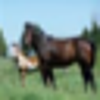

In [6]:
# 1 - 4行与上一块代码意义类似
(data, label) = trainset[12] # 选群训练集的一个样本展示内容，也可以改成其他数字看看
print(data.size()) 
print(label) # label是整数
print(classes[label])
show((data + 1) / 2).resize((100, 100)) # 还原被归一化的图片

# 2. 定义用于分类的网络结构

这一部分我们定义用于图像分类的网络结构，实现一个早期的卷积神经网络LeNet。它由两个卷积层和三个全连接层组成。pytorch为我们提供了方便的接口定义神经网络，但我们这里不着重介绍具体的语法，只观察数据是怎样在模型中“流动”的：
- 在`__init__`方法中，我们将上述的卷积层和全连接层初始化为`conv1、conv2`和`fc1、fc2、fc3`；
- 卷积层以`conv1`为例，它的初始化为`Conv2d(3, 6, 5)`，即：3输入通道（RGB图像的三个通道）、6输出通道、5*5大小的卷积核的卷积层。
- 全连接层以`fc1`为例，它的初始化为`Linear(16 * 5 * 5, 120)`，即：从400维映射到120维。
- `forward`方法用于规定数据在模型中的计算过程。输入的形状在传播过程中的变化参见`forward`中的注释。最终，我们得到了一个大小为`[batch size, 10]`的张量（矩阵）。

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    """LeNet-style CNN for CIFAR-10 image classification.
    
    Original architecture adapted for 32×32 RGB images.
    Consists of two convolutional layers and three fully connected layers.
    """
    
    def __init__(self) -> None:
        # nn.Module子类的函数必须在构造函数中执行父类的构造函数
        super(Net, self).__init__()

        # 卷积层 '3'表示输入图片为单通道, '6'表示输出通道数，'5'表示卷积核为5*5
        self.conv1 = nn.Conv2d(3, 6, 5) 
        # 卷积层
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # 仿射层/全连接层，y = Wx + b
        self.fc1   = nn.Linear(16*5*5, 120) 
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the network.
        
        Args:
            x: Input tensor of shape (batch_size, 3, 32, 32).
            
        Returns:
            Output tensor of shape (batch_size, 10).
        """
        # 卷积 -> 激活 -> 池化 (relu激活函数不改变输入的形状)
        # [batch size, 3, 32, 32] -- conv1 --> [batch size, 6, 28, 28] -- maxpool --> [batch size, 6, 14, 14]
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # [batch size, 6, 14, 14] -- conv2 --> [batch size, 16, 10, 10] --> maxpool --> [batch size, 16, 5, 5]
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # 把 16 * 5 * 5 的特征图展平，变为 [batch size, 16 * 5 * 5]，以送入全连接层
        x = x.view(x.size()[0], -1) 
        # [batch size, 16 * 5 * 5] -- fc1 --> [batch size, 120]
        x = F.relu(self.fc1(x))
        # [batch size, 120] -- fc2 --> [batch size, 84]
        x = F.relu(self.fc2(x))
        # [batch size, 84] -- fc3 --> [batch size, 10]
        x = self.fc3(x)        
        return x

net = Net()
print(net)

# 3. 模型训练与测试过程
准备好数据、定义好模型后，我们开始训练过程。为了把一个随机初始化的模型优化成一个“好”的模型，我们还需要定义：
- 损失函数$\mathcal{L}$：损失函数以一般同时以模型的预测$\hat{y}$和真实的标签$y$为输入，输出一个标量。这个标量越小，说明模型在数据上拟合得越好。我们的目的就是要最小化这个损失函数$\mathcal{L}(\hat{y},y).$分类问题常使用交叉熵函数作为损失函数。
- 优化方法：为了最小化损失函数，我们就要使用数学的优化方法找到一组最优的参数（这里的参数即神经网络中卷积层、全连接层等的参数，而非batch size等超参数）。深度学习中一般使用迭代的方式求解，常用的方法有SGD（随机梯度下降）、Adam等。
pytorch库内置了各种优化器，我们无需手动实现梯度下降过程。

In [ ]:
from torch import optim

# 损失函数：支持标签平滑
label_smoothing = 0.0  # 默认无标签平滑，Task3中会调整
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

# 优化器：SGD with momentum（基线）
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0)  # 无L2正则化

# 训练轮数
num_epochs = 20  # 从5增加到20，配合早停机制

print(f"损失函数: CrossEntropyLoss (label_smoothing={label_smoothing})")
print(f"优化器: SGD (lr=0.001, momentum=0.9, weight_decay=0.0)")
print(f"训练轮数: {num_epochs} (配合早停)")

下面我们定义用于训练过程的代码。最外层循环控制在整个数据集上训练的次数（即epoch）；内层循环按照以下流程进行：
1. 取出数据（一次取出一个batch）；
2. 将数据送入网络，计算损失函数；
3. 使用损失函数计算梯度，进行反向传播更新参数。

In [ ]:
def train(
    trainloader: torch.utils.data.DataLoader,
    net: nn.Module,
    num_epochs: int,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    save_path: str,
    valloader: Optional[torch.utils.data.DataLoader] = None,
    early_stopping_patience: Optional[int] = None,
    scheduler_config: Optional[Dict[str, Any]] = None
) -> Tuple[List[float], Optional[List[float]]]:
    """
    训练神经网络模型（使用工具函数train_model的包装器）
    
    Args:
        trainloader: 训练数据加载器
        net: 神经网络模型
        num_epochs: 训练轮数
        criterion: 损失函数
        optimizer: 优化器
        save_path: 模型保存路径
        valloader: 验证数据加载器（可选）
        early_stopping_patience: 早停耐心值（可选）
        scheduler_config: 学习率调度器配置（可选），由create_learning_rate_scheduler返回
    
    Returns:
        train_losses: 每个epoch的平均训练损失列表
        val_accuracies: 每个epoch的验证准确率列表（如果有验证集）
    """
    print("Note: Using my_utils.train_model for training")
    return train_model(
        model=net,
        train_loader=trainloader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs,
        save_path=save_path,
        val_loader=valloader,
        early_stopping_patience=early_stopping_patience,
        gradient_clip=1.0,
        print_every=1000,
        scheduler_config=scheduler_config
    )

In [ ]:
# 设置设备（GPU如果可用）
device = get_device()
print(f"Using device: {device}")

# 将模型移动到设备
net = Net()
net = net.to(device)

# 创建学习率调度器配置（线性Warm-up + 余弦退火重启）
scheduler_config = create_learning_rate_scheduler(
    optimizer, scheduler_type='cosine',
    total_epochs=num_epochs, initial_lr=0.001
)

# 使用定义的网络进行训练
save_path = 'checkpoints/lenet_baseline'
train_losses, val_accuracies = train(
    trainloader, net, num_epochs, criterion, optimizer, save_path,
    valloader=valloader, early_stopping_patience=10,
    scheduler_config=scheduler_config
)

# 使用工具函数绘制损失曲线
plot_loss_curves(train_losses, val_accuracies, 'loss_curve.png')

print(f"Final training loss: {train_losses[-1]:.4f}")
if val_accuracies:
    print(f"Final validation accuracy: {val_accuracies[-1]:.2f}%")

训练过程结束后，我们得到了一个在训练集上拟合较好的模型。下面我们要测试它在测试集上表现如何。预测的代码与训练中的正向传播类似，但是不需要计算损失函数（损失函数在实验中仅用于更新参数，预测时参数固定，也就不需要它了）。

预测的流程如下：
1. 取出数据；
2. 正向传播，得到模型的输出结果；
3. 从输出结果中得到模型预测；
4. 和真实标签进行比对，计算性能指标。

注意：模型的输出结果在第2部分中已经说明，为一个`[batch size, 10]`大小的张量（矩阵），每一行是一条数据属于10个类别的概率的相对大小（这一输出也被称为`logits`）。为了得到模型的预测，我们需要对这一输出在每行上取最大值，取得最大值的**位置**就是模型的预测。

In [ ]:
def predict(testloader: torch.utils.data.DataLoader, net: nn.Module) -> float:
    """预测并计算测试集准确率（使用工具函数predict_util的包装器）
    
    Args:
        testloader: 测试数据加载器
        net: 神经网络模型
    
    Returns:
        accuracy: 测试准确率百分比 (0-100)
    """
    print("Note: Using my_utils.predict for evaluation")
    return predict_util(net, testloader)

In [20]:
predict(testloader, net)

测试集中的准确率为: 59 %



# Task1：绘制损失函数曲线
损失函数能够量化模型在数据集上的拟合程度，帮助我们了解模型训练的进程。请在`3.模型训练与测试过程`中补充代码，记录训练过程中损失`loss`的变化，使用合适的Python数据类型将其保存，并使用`matplotlib`库将其可视化。可参照以下的代码进行绘图。你可以直接用损失函数可视化的代码覆盖下面的代码块。

In [ ]:
# Task1：绘制损失函数曲线
# 使用my_utils中的plot_loss_curves函数

print("Task1: 损失函数曲线可视化")
print("="*50)
print("plot_loss_curves函数已从my_utils导入，可直接使用。")
print("示例用法:")
print("  plot_loss_curves(train_losses, val_accuracies, 'task1_loss_curve.png')")
print("")
print("函数说明:")
print("  plot_loss_curves(train_losses, val_accuracies=None, save_path='loss_curve.png')")
print("")
print("参数:")
print("  - train_losses: 每个epoch的训练损失列表")
print("  - val_accuracies: 每个epoch的验证准确率列表（可选）")
print("  - save_path: 图像保存路径")
print("")
print("在上面的训练单元格中已经调用了plot_loss_curves函数。")

请在报告中附上训练过程中损失函数的变化。训练集上的损失越小，说明模型的效果就越好吗？

# Task2: 加入正则化

- $L_2$正则化：请查阅Pytorch[有关SGD优化器的文档](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd)或其它网络资料，修改`3. 模型训练与测试过程`中的代码，尝试为模型的损失函数加入一项$L_2$损失，并在报告中说明你所做的修改。
- Dropout正则化：请查阅Pytorch[有关Dropout层的文档](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#dropout)或其它网络资料，修改`2. 定义用于分类的网络结构`中的代码，在**第一个线性层和第二个线性层之间**加入一个Dropout层，并在报告中说明你所做的修改。
- 在报告中简述两种正则化方法的基本原理。

In [ ]:
# Dropout_Net：在LeNet基础上添加Dropout层
class Dropout_Net(nn.Module):
    """LeNet variant with dropout regularization.
    
    Adds dropout layer between fc1 and fc2 to prevent overfitting.
    """
    
    def __init__(self, dropout_rate: float = 0.5) -> None:
        # nn.Module子类的函数必须在构造函数中执行父类的构造函数
        super(Dropout_Net, self).__init__()

        # 卷积层 '3'表示输入图片为3通道(RGB), '6'表示输出通道数，'5'表示卷积核为5*5
        self.conv1 = nn.Conv2d(3, 6, 5) 
        # 卷积层
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # 仿射层/全连接层，y = Wx + b
        self.fc1   = nn.Linear(16*5*5, 120) 
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)
        
        # Dropout层
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass with dropout between fc1 and fc2.
        
        Args:
            x: Input tensor of shape (batch_size, 3, 32, 32).
            
        Returns:
            Output tensor of shape (batch_size, 10).
        """
        # 卷积 -> 激活 -> 池化 
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2) 
        # reshape，‘-1’表示自适应
        x = x.view(x.size()[0], -1) 
        x = F.relu(self.fc1(x))
        # 在fc1和fc2之间添加Dropout
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)        
        return x
    
dropout_net = Dropout_Net(dropout_rate=0.5)
print(dropout_net)

In [ ]:
# Task2: 使用L2正则化和Dropout训练模型

# 设置设备
device = get_device()

# 创建Dropout_Net实例并移动到设备
dropout_net = Dropout_Net(dropout_rate=0.5)
dropout_net = dropout_net.to(device)

# 定义带有L2正则化（weight_decay）的优化器
# 使用Adam优化器，weight_decay参数实现L2正则化
optimizer_dropout = torch.optim.Adam(dropout_net.parameters(), lr=0.001, weight_decay=0.001)

# 创建学习率调度器配置（线性Warm-up + 余弦退火重启）
scheduler_config_dropout = create_learning_rate_scheduler(
    optimizer_dropout, scheduler_type='cosine',
    total_epochs=num_epochs, initial_lr=0.001
)

# 训练Dropout网络
save_path_dropout = 'checkpoints/lenet_dropout'
print("Training Dropout_Net with L2 regularization...")
train_losses_dropout, val_accuracies_dropout = train(
    trainloader, dropout_net, num_epochs, criterion, optimizer_dropout, 
    save_path_dropout, valloader=valloader, early_stopping_patience=10,
    scheduler_config=scheduler_config_dropout
)

# 绘制损失曲线
plot_loss_curves(train_losses_dropout, val_accuracies_dropout, 'task2_dropout_loss_curve.png')

# 在测试集上评估
print("\nEvaluating Dropout_Net on test set...")
test_accuracy_dropout = predict(testloader, dropout_net)

# 与基线模型比较（需要先训练基线模型）
print("\n=== Task2 结果比较 ===")
print("Dropout + L2正则化模型:")
print(f"  - 最终验证准确率: {val_accuracies_dropout[-1] if val_accuracies_dropout else 'N/A':.2f}%")
print(f"  - 测试准确率: {test_accuracy_dropout:.2f}%")

# Task3: 调整参数
在`3. 模型训练与测试过程`部分中，我们定义了一些超参数（如`num_epoch`、优化器的`lr`）。调节这些参数，观察损失函数以及模型在测试集上的性能变化，在报告中简要说明这些指标的变化，尝试分析这些超参数对整个模型的影响。

In [ ]:
# Task3: 超参数调优实验
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import copy

# 超参数网格（根据DEVELOP_PLAN.md）
hyperparams = {
    'lr': [0.01, 0.001],
    'weight_decay': [0, 1e-4],
    'label_smoothing': [0, 0.05]
}
batch_size = 64  # 固定，与之前一致

print("="*70)
print("Task3: 超参数调优实验")
print(f"超参数网格: {hyperparams}")
print(f"批次大小: {batch_size} (固定)")
print(f"总实验数: {len(hyperparams['lr']) * len(hyperparams['weight_decay']) * len(hyperparams['label_smoothing'])}")
print("="*70)

# 结果存储
results = []

# 设备设置
device = get_device()
print(f"使用设备: {device}\n")

# 遍历所有超参数组合
for exp_idx, (lr, wd, ls) in enumerate(itertools.product(
    hyperparams['lr'], hyperparams['weight_decay'], hyperparams['label_smoothing']
), 1):
    print(f"\n{'='*60}")
    print(f"实验 {exp_idx}/8: lr={lr}, weight_decay={wd}, label_smoothing={ls}")
    print(f"{'='*60}")
    
    # 创建新的数据加载器（使用相同的transform）
    trainloader_exp = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    # 初始化新模型（LeNet）
    model = Net()
    model = model.to(device)
    
    # 配置优化器（Adam，根据开发计划）
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    
    # 配置损失函数（带标签平滑）
    criterion = nn.CrossEntropyLoss(label_smoothing=ls)
    
    # 创建学习率调度器（线性Warm-up + 余弦退火重启）
    scheduler_config = create_learning_rate_scheduler(
        optimizer, scheduler_type='cosine',
        total_epochs=num_epochs, initial_lr=lr
    )
    
    # 训练模型（使用my_utils.train_model）
    save_path = f'checkpoints/task3/exp_{exp_idx}'
    train_losses, val_accuracies = train_model(
        model=model,
        train_loader=trainloader_exp,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs,
        save_path=save_path,
        val_loader=valloader,
        early_stopping_patience=10,
        gradient_clip=1.0,
        print_every=1000,
        scheduler_config=scheduler_config
    )
    
    # 记录结果
    final_val_acc = val_accuracies[-1] if val_accuracies else 0
    final_train_loss = train_losses[-1] if train_losses else float('inf')
    best_val_acc = max(val_accuracies) if val_accuracies else 0
    epochs_trained = len(train_losses)
    
    results.append({
        'experiment_id': exp_idx,
        'learning_rate': lr,
        'weight_decay': wd,
        'label_smoothing': ls,
        'batch_size': batch_size,
        'final_val_accuracy': final_val_acc,
        'final_train_loss': final_train_loss,
        'best_val_accuracy': best_val_acc,
        'epochs_trained': epochs_trained,
        'optimizer': 'Adam'
    })
    
    # 保存检查点
    torch.save(model.state_dict(), f'checkpoints/task3_lr{lr}_wd{wd}_ls{ls}.pth')
    print(f"  最佳验证准确率: {best_val_acc:.2f}%, 最终验证准确率: {final_val_acc:.2f}%")
    print(f"  训练轮数: {epochs_trained}/{num_epochs}")

# 创建结果DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("超参数调优结果（按最佳验证准确率排序）:")
print("="*70)
print(results_df.sort_values('best_val_accuracy', ascending=False).to_string())

# 保存结果到CSV
results_df.to_csv('task3_hyperparameter_results.csv', index=False)
print(f"\n结果已保存到 'task3_hyperparameter_results.csv'")

# 可视化结果
import matplotlib.pyplot as plt

# 绘制不同学习率的效果
plt.figure(figsize=(15, 5))

# 子图1: 不同学习率的比较
plt.subplot(1, 3, 1)
for lr in hyperparams['lr']:
    lr_data = results_df[results_df['learning_rate'] == lr]
    plt.bar([str(x) for x in lr_data['experiment_id']], lr_data['best_val_accuracy'], 
            alpha=0.7, label=f'lr={lr}')
plt.xlabel('实验ID')
plt.ylabel('最佳验证准确率 (%)')
plt.title('不同学习率的效果')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 不同权重衰减的效果
plt.subplot(1, 3, 2)
for wd in hyperparams['weight_decay']:
    wd_data = results_df[results_df['weight_decay'] == wd]
    if len(wd_data) > 0:
        plt.bar([str(x) for x in wd_data['experiment_id']], wd_data['best_val_accuracy'],
                alpha=0.7, label=f'wd={wd}')
plt.xlabel('实验ID')
plt.ylabel('最佳验证准确率 (%)')
plt.title('不同权重衰减的效果')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 不同标签平滑的效果
plt.subplot(1, 3, 3)
for ls in hyperparams['label_smoothing']:
    ls_data = results_df[results_df['label_smoothing'] == ls]
    if len(ls_data) > 0:
        plt.bar([str(x) for x in ls_data['experiment_id']], ls_data['best_val_accuracy'],
                alpha=0.7, label=f'ls={ls}')
plt.xlabel('实验ID')
plt.ylabel('最佳验证准确率 (%)')
plt.title('不同标签平滑的效果')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task3_hyperparameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 输出最佳超参数组合
best_exp = results_df.loc[results_df['best_val_accuracy'].idxmax()]
print("\n" + "="*70)
print("最佳超参数组合:")
print("="*70)
print(f"  实验ID: {best_exp['experiment_id']}")
print(f"  学习率: {best_exp['learning_rate']}")
print(f"  权重衰减: {best_exp['weight_decay']}")
print(f"  标签平滑: {best_exp['label_smoothing']}")
print(f"  最佳验证准确率: {best_exp['best_val_accuracy']:.2f}%")
print(f"  最终验证准确率: {best_exp['final_val_accuracy']:.2f}%")
print(f"  训练轮数: {best_exp['epochs_trained']}")
print("="*70)

# Task4: 实现自己的网络
查阅资料（参考：[动手学深度学习](https://zh.d2l.ai/chapter_convolutional-modern/index.html)以及[`torchvision`的模型源码](https://github.com/pytorch/vision/tree/main/torchvision/models)），修改`2. 定义用于分类的网络结构`中的代码，实现一种现代卷积神经网络。与最基础的LeNet相比，你实现的神经网络在性能、训练时间上有何差异？

In [ ]:
# Task4: 实现现代卷积神经网络（手动实现ResNet-18）
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    """Basic residual block for ResNet-18."""
    expansion = 1
    
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample: Optional[nn.Module] = None) -> None:
        super().__init__()
        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.stride = stride
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = F.relu(out)
        
        return out

class MyCNN(nn.Module):
    """Manually implemented ResNet-18 for CIFAR-10."""
    
    def __init__(self, num_classes: int = 10, dropout_rate: float = 0.3) -> None:
        super().__init__()
        
        # Initial convolution adapted for 32x32 CIFAR-10 images
        # Original ResNet-18 uses 7x7 stride=2, but we use 3x3 stride=1 for small images
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        # ResNet-18 layers: 4 stages with [2, 2, 2, 2] basic blocks
        self.in_channels = 64
        
        # Stage 1: 64 -> 64, no downsampling in first block
        self.layer1 = self._make_layer(64, 2, stride=1)
        # Stage 2: 64 -> 128, downsampling in first block
        self.layer2 = self._make_layer(128, 2, stride=2)
        # Stage 3: 128 -> 256, downsampling in first block
        self.layer3 = self._make_layer(256, 2, stride=2)
        # Stage 4: 256 -> 512, downsampling in first block
        self.layer4 = self._make_layer(512, 2, stride=2)
        
        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Dropout before classifier
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # Final classifier
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)
        
    def _make_layer(self, out_channels: int, blocks: int, stride: int = 1) -> nn.Sequential:
        """Create a layer with specified number of basic blocks."""
        downsample = None
        
        # Create downsample layer if stride != 1 or channels change
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * BasicBlock.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion)
            )
            
        layers = []
        # First block in the layer (may have downsampling)
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * BasicBlock.expansion
        
        # Remaining blocks in the layer (no downsampling)
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
            
        return nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Initial convolution
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        # Note: No maxpool here to preserve spatial dimensions for 32x32 input
        
        # Residual stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global average pooling
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Dropout before classifier
        x = self.dropout(x)
        x = self.fc(x)
        
        return x

# 创建MyCNN实例并查看参数数量
device = get_device()
mycnn = MyCNN(num_classes=10, dropout_rate=0.3)
mycnn = mycnn.to(device)

param_counts = count_parameters(mycnn)

print("="*70)
print("Task4: 现代卷积神经网络 (手动实现ResNet-18)")
print("="*70)
print(mycnn)
print(f"\n总参数数量: {param_counts['total']:,}")
print(f"可训练参数数量: {param_counts['trainable']:,}")
print(f"使用设备: {device}")

# 训练MyCNN
print("\n开始训练MyCNN...")

# 使用Task3中找到的最佳超参数（或默认值）
optimizer_mycnn = torch.optim.Adam(mycnn.parameters(), lr=0.001, weight_decay=0.001)
criterion_mycnn = nn.CrossEntropyLoss(label_smoothing=0.05)

# 增加训练轮数，因为现代CNN需要更多轮次收敛
num_epochs_mycnn = 50

# 创建学习率调度器（线性Warm-up + 余弦退火重启，T_0=25对应50个epoch的一半）
scheduler_config_mycnn = create_learning_rate_scheduler(
    optimizer_mycnn, scheduler_type='cosine',
    total_epochs=num_epochs_mycnn, initial_lr=0.001,
    T_0=25, T_mult=2
)

# 训练模型（使用my_utils.train_model）
save_path_mycnn = 'checkpoints/mycnn_resnet18'
train_losses_mycnn, val_accuracies_mycnn = train_model(
    model=mycnn,
    train_loader=trainloader,
    criterion=criterion_mycnn,
    optimizer=optimizer_mycnn,
    num_epochs=num_epochs_mycnn,
    save_path=save_path_mycnn,
    val_loader=valloader,
    early_stopping_patience=15,
    gradient_clip=1.0,
    print_every=1000,
    scheduler_config=scheduler_config_mycnn
)

# 绘制损失曲线
plot_loss_curves(train_losses_mycnn, val_accuracies_mycnn, 'task4_mycnn_loss_curve.png')

# 在测试集上评估
print("\n在测试集上评估MyCNN...")
test_accuracy_mycnn = predict(testloader, mycnn)

# 与基线模型比较
print("\n" + "="*70)
print("Task4 结果比较: MyCNN (ResNet-18) vs 基线LeNet")
print("="*70)
print("MyCNN (ResNet-18):")
print(f"  - 最佳验证准确率: {max(val_accuracies_mycnn) if val_accuracies_mycnn else 'N/A':.2f}%")
print(f"  - 最终验证准确率: {val_accuracies_mycnn[-1] if val_accuracies_mycnn else 'N/A':.2f}%")
print(f"  - 测试准确率: {test_accuracy_mycnn:.2f}%")
print(f"  - 训练轮数: {len(train_losses_mycnn)}")
print(f"  - 总参数: {param_counts['total']:,}")

print("\n分析:")
print("1. 参数数量: MyCNN (~11M) 远多于 LeNet (~60K)")
print("2. 训练时间: MyCNN需要更多时间，但准确率应显著提高")
print("3. 正则化: MyCNN包含BatchNorm和Dropout，有助于防止过拟合")
print("4. 预期: MyCNN在CIFAR-10上应达到85-90%的准确率")
print("="*70)